In [2]:
import pandas as pd 
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import json
import mne
import numpy as np
from tqdm import tqdm
import re
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from multiprocessing import Pool
import warnings

warnings.filterwarnings("ignore")

os.chdir('../..')

# Load Morlet PSDs

In [11]:
#loaded = np.load('./Generated/Spectrums/psds_array_morlet.npz')
loaded = np.load('C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Generated/Spectrums/psds_array_morlet.npz')

results_arr = []

i = 0
while f'psd_{i}' in loaded:
    psd = loaded[f'psd_{i}']
    s_id = int(loaded[f'subject_id_{i}'])
    t_id = int(loaded[f'trial_id_{i}'])
    gender = str(loaded[f'gender_{i}'])
    handiness = str(loaded[f'handiness_{i}'])
    age = int(loaded[f'age_{i}'])
    
    results_arr.append([psd, s_id, t_id, gender, handiness, age])
    i += 1

psd, s_id, t_id, gender, handiness, age = results_arr[0]
psd.shape

(63, 80)

In [12]:
# Parse into two lists will be used furthere
psds_array = [item[0] for item in results_arr]
psds_array = np.array(psds_array)                            # Convert list of PSDs to a numpy array
psds_array = psds_array.reshape((psds_array.shape[0], -1))   # Vectorize 

metadata = [item[1:] for item in results_arr]

psds_array.shape

(31, 5040)

### Normalize Each Spectrum
Why not to normalize by channels? - Because the chennel relevance to each other may be lost. For instance some chanels may have higher power for particular freq band.

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
psds_array = scaler.fit_transform(psds_array)

# Dimentionality Reduction
Every method produces `reduced_data` variable wich is `27xN` shape, where `N` is the reduction dimentionality.

### PCA

In [14]:
from sklearn.decomposition import PCA

# Assuming 'psds_array' is your high-dimensional data
N = 18
pca = PCA(n_components=N, random_state=42)
reduced_data = pca.fit_transform(psds_array)
reduced_data.shape

(31, 18)

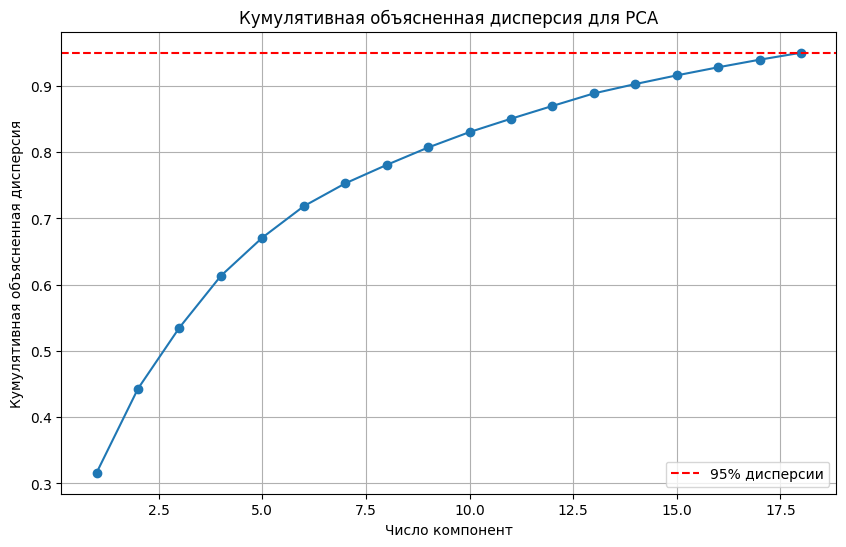

In [15]:
# Анализ объясненной дисперсии
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Визуализация кумулятивной дисперсии
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Число компонент')
plt.ylabel('Кумулятивная объясненная дисперсия')
plt.title('Кумулятивная объясненная дисперсия для PCA')
plt.grid(True)
plt.legend()
plt.show()

# Best 17 dim

# Clusterization
* `KNN` - 
* `DBSCAN` - 
* `HDBSCAN` -
* `GMM` -
* `Spectral Clustering` -
* `Agglomerative` - 

### KNN
Best for `PCA` k=2 (Но оно всеравно меньше 0.5, а значит не столь надежно)

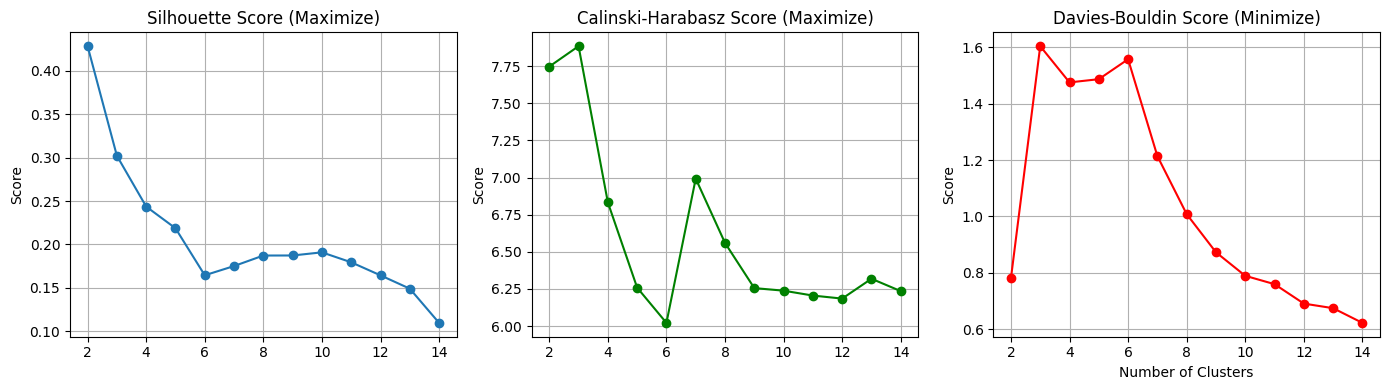

In [16]:
from sklearn.cluster import KMeans

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [17]:
k = 2  # предположительное количество кластеров
kmeans = KMeans(n_clusters=k, random_state=42)
labels_knn = kmeans.fit_predict(reduced_data)

### DBSCAN
Best for `PCA` - Излом на 90

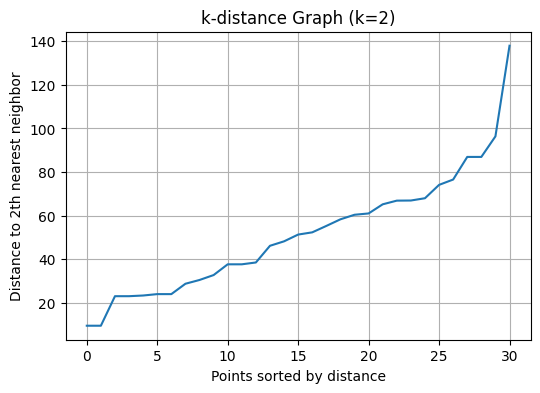

In [18]:
from sklearn.neighbors import NearestNeighbors

min_samples = 2
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(reduced_data)
distances, indices = neighbors_fit.kneighbors(reduced_data)

# берем расстояние до k-го соседа (по столбцу)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title(f"k-distance Graph (k={min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.grid(True)
plt.show()



In [19]:
from sklearn.cluster import DBSCAN

# DBSCAN clustering in high-dimensional space
dbscan = DBSCAN(eps=90, min_samples=2)  # eps можно варьировать
labels_dbscan = dbscan.fit_predict(reduced_data)

### HDBSCAN

In [20]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=2)
labels_hdbscan = clusterer.fit_predict(reduced_data)

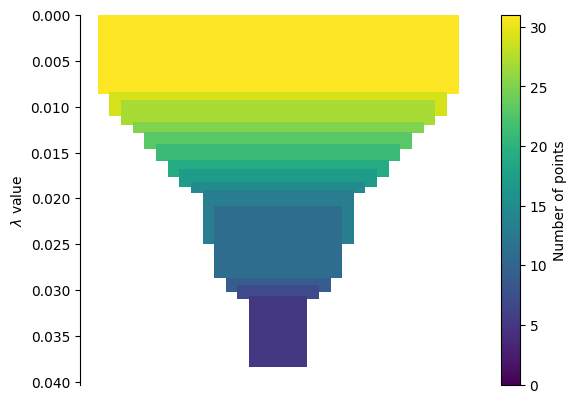

In [21]:
clusterer.condensed_tree_.plot()
pass

### GMM
`n_components`: количество гауссовых компонентов. Подбирается через BIC:

BIC (Bayesian Information Criterion) — это метрика, которая балансирует:

качество подгонки модели (log-likelihood — чем выше, тем лучше)

сложность модели (штраф за число параметров)


Best for `PCA` - minimum bic is for 5 components

Best for `UMAP` - minimum bic is for 3 components

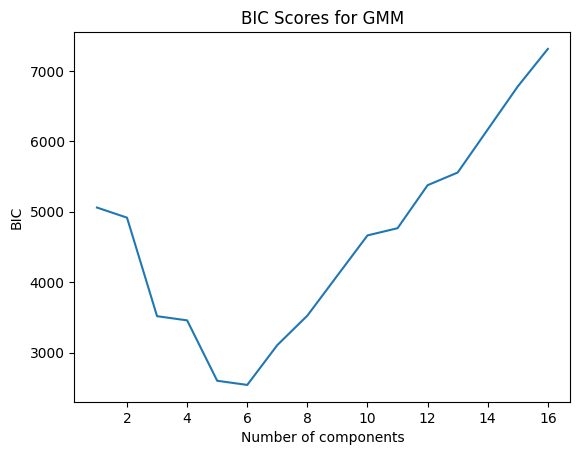

In [22]:
from sklearn.mixture import GaussianMixture

bic_scores = []
for n in range(1, 17):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(reduced_data)
    bic_scores.append(gmm.bic(reduced_data))

plt.plot(range(1, 17), bic_scores)
plt.title("BIC Scores for GMM")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.show()

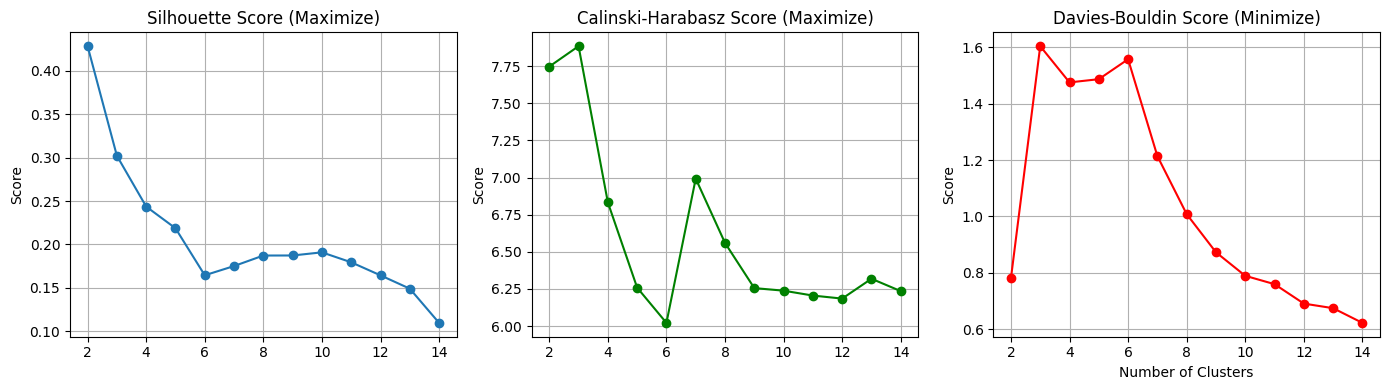

In [33]:
silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels = gmm.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [23]:
gmm = GaussianMixture(n_components=6, random_state=42)
labels_gmm = gmm.fit_predict(reduced_data)

### Spectral Clustering

Best for `PCA` - 4 clusters (max score)

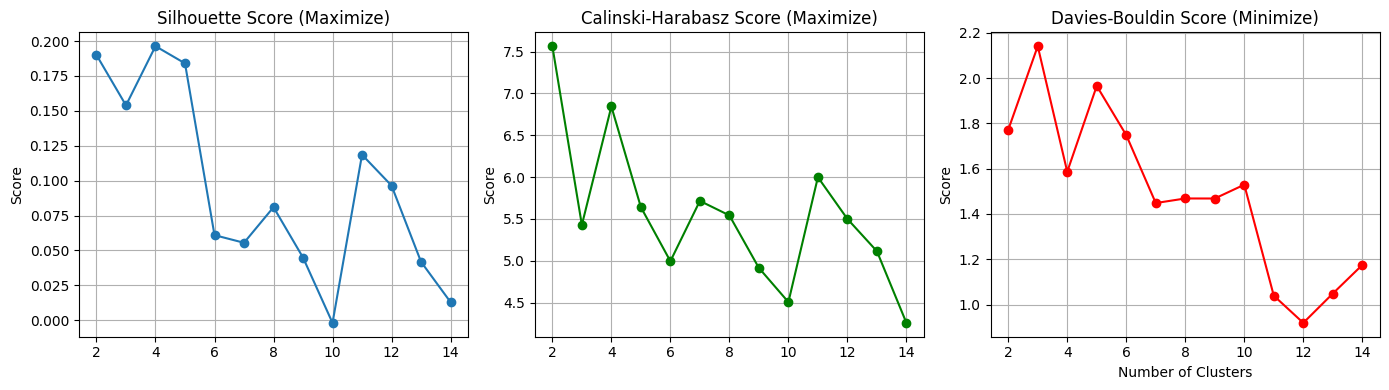

In [24]:
from sklearn.cluster import SpectralClustering

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    spec = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42)
    labels = spec.fit_predict(psds_array)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [35]:
spec = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=42)
labels_spec_clust = spec.fit_predict(psds_array)

### Agglomerative

Best for `PCA` - 3 clusters (max score)

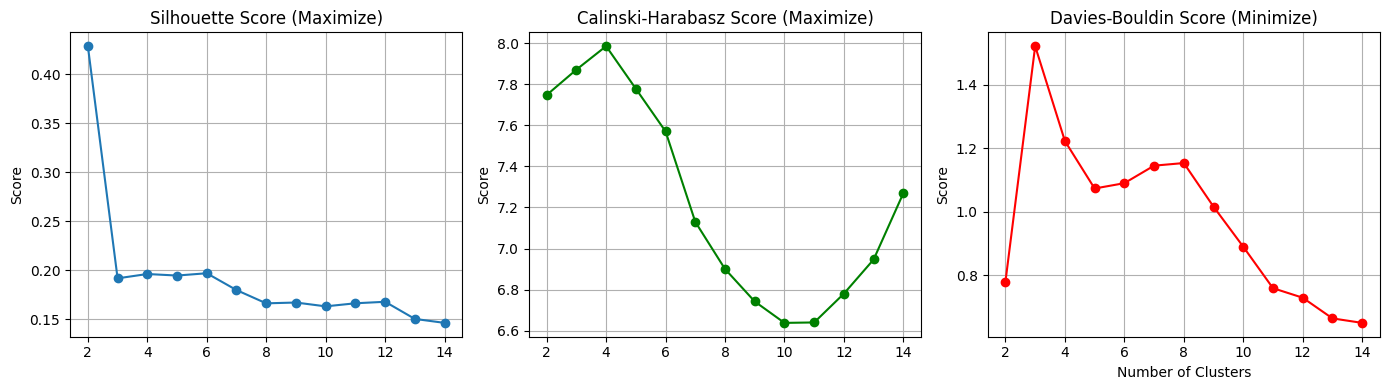

In [25]:
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 15)

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(reduced_data)

    # Метрики
    sil = silhouette_score(reduced_data, labels)
    cal = calinski_harabasz_score(reduced_data, labels)
    dav = davies_bouldin_score(reduced_data, labels)

    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_scores.append(dav)

# Визуализация всех трех метрик
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(k_range, silhouette_scores, marker='o')
axs[0].set_title("Silhouette Score (Maximize)")
axs[0].set_ylabel("Score")
axs[0].grid(True)

axs[1].plot(k_range, calinski_scores, marker='o', color='green')
axs[1].set_title("Calinski-Harabasz Score (Maximize)")
axs[1].set_ylabel("Score")
axs[1].grid(True)

axs[2].plot(k_range, davies_scores, marker='o', color='red')
axs[2].set_title("Davies-Bouldin Score (Minimize)")
axs[2].set_xlabel("Number of Clusters")
axs[2].set_ylabel("Score")
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Иерархическая кластеризация с заданным числом кластеров
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agglomerative = model.fit_predict(reduced_data)

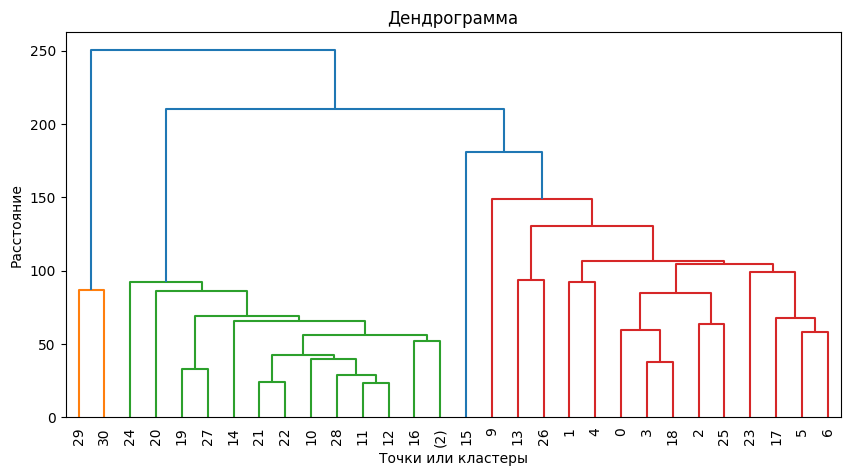

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(reduced_data, method='ward')  # метод linkage должен соответствовать
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90.)
plt.title('Дендрограмма')
plt.xlabel('Точки или кластеры')
plt.ylabel('Расстояние')
plt.show()

In [28]:
from datetime import datetime, time as dtime

# Используем тот же файл и приём, что в Compute_*_All
file_path = 'C:/Users/dasga/PycharmProjects/EEG/EEG-Image-Reconstruction/Supplementary/Experiment_Metadata.xlsx'
df_raw = pd.read_excel(file_path, header=1)

# Переименования как там
df_raw = df_raw.rename(columns={
    'Subject ID'     : 'Subject_id',
    'Имя'            : 'Name',
    'Фамилия'        : 'Surname',
    'Дата Рождения'  : 'Birthdate',
    'Пол'            : 'Gender',
    'Правша / Левша' : 'Handiness',
    'Время'          : 'Time',       # если колонка на рус
})

# Преобразование пола/латерализации в латиницу (как в compute_all)
gender_map = {'М':'m', 'Ж':'f', 'м':'m', 'ж':'f'}
if 'Gender' in df_raw.columns:
    df_raw['Gender'] = df_raw['Gender'].map(gender_map).fillna(df_raw['Gender'])

hand_map = {'Правша':'r', 'Левша':'l', 'правша':'r', 'левша':'l'}
if 'Handiness' in df_raw.columns:
    df_raw['Handiness'] = df_raw['Handiness'].map(hand_map).fillna(df_raw['Handiness'])

# Возраст (как в твоих Compute): Birthdate -> Age и удаляем Birthdate
if 'Birthdate' in df_raw.columns:
    df_raw['Birthdate'] = pd.to_datetime(df_raw['Birthdate'], dayfirst=True, errors='coerce')
    today = pd.Timestamp.today().normalize()
    def calc_age(bd):
        if pd.isna(bd): return 0
        years = today.year - bd.year
        if (today.month, today.day) < (bd.month, bd.day): years -= 1
        return int(years)
    df_raw['Age'] = df_raw['Birthdate'].apply(calc_age).fillna(0).astype(int)
    df_raw = df_raw.drop(columns=['Birthdate'])

# Индекс — Subject_id
if 'Subject_id' not in df_raw.columns:
    raise KeyError("В метаданных нет 'Subject_id' после переименования.")
subject_metadata = df_raw.set_index('Subject_id')

# Аккуратный парсинг времени: поддержка excel-чисел и строк/дат
def _to_time(series: pd.Series) -> pd.Series:
    if series.name is None:
        series.name = 'Time'
    s = series
    if np.issubdtype(s.dtype, np.number):
        vals = s.to_numpy(dtype=float)
        if np.nanmax(vals) <= 1.5:  # доля суток
            secs = np.nan_to_num(vals) * 24 * 3600.0
            return pd.to_timedelta(secs, unit='s').map(lambda td: (pd.Timestamp.min + td).time())
    dt = pd.to_datetime(s, errors='coerce')
    if dt.isna().any():
        raise ValueError("Часть значений времени не распарсилась (NaT). Проверь формат Time.")
    return dt.dt.time

# Находим колонку времени
time_col = 'Time' if 'Time' in subject_metadata.columns else None
if time_col is None:
    # fallback — попробуем популярные названия
    for cand in ['Время начала записи']:
        if cand in subject_metadata.columns:
            subject_metadata = subject_metadata.rename(columns={cand: 'Time'})
            time_col = 'Time'; break
if time_col is None:
    raise KeyError("Не нашли колонку 'Time' в метаданных.")

subject_metadata['__time'] = _to_time(subject_metadata['Time'])
subject_metadata[['__time']].head()


,__time
Subject_id,
1,18:00:00
2,20:00:00
3,13:00:00
4,16:00:00
5,19:00:00


# Search Space Visualization

In [29]:
from sklearn.decomposition import PCA

# Assuming 'psds_array' is your high-dimensional data
N = 3
pca = PCA(n_components=N, random_state=42)
reduced_data = pca.fit_transform(psds_array)
reduced_data.shape

(31, 3)

In [ ]:
# from sklearn.manifold import TSNE

# N = 3  # Размерность после снижения
# reducer = TSNE(n_components=N, random_state=42, perplexity=10, max_iter=10000, metric='euclidean')
# reduced_data = reducer.fit_transform(psds_array)

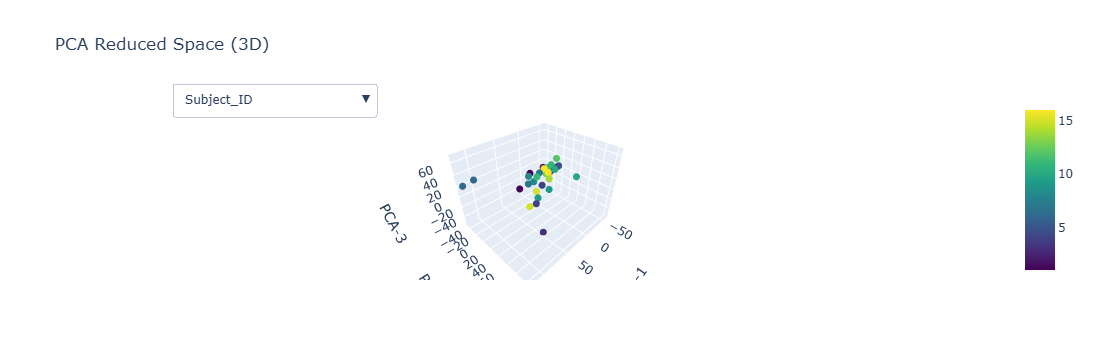

In [41]:
from plotly import colors as pc

method = 'PCA'
dim = 3  # Can be 2 or 3

subject_ids = [meta[0] for meta in metadata]
trial_ids = [meta[1] for meta in metadata]
gender = [meta[2] for meta in metadata]
handiness = [meta[3] for meta in metadata]
age = [meta[4] for meta in metadata]

# Маппим время к каждой записи по Subject_ID (если в Excel есть Trial_id — можно расширить merge)
times = []
for sid in subject_ids:
    try:
        t = subject_metadata.loc[int(sid), '__time']
        # если у субъекта несколько строк в Excel — берём первую
        if isinstance(t, pd.Series):
            t = t.iloc[0]
        times.append(t)
    except Exception:
        times.append(None)

def _cond_from_time(t, day_start=10, day_end=18, eve_start=18, eve_end=24):
    if t is None: return 'other'
    h = t.hour
    in_day = (day_start <= h < day_end) if day_start < day_end else (h >= day_start or h < day_end)
    in_eve = (eve_start <= h < (eve_end % 24)) if eve_start < eve_end else (h >= eve_start or h < (eve_end % 24))
    if in_day: return 'day'
    if in_eve: return 'evening'
    return 'other'
conditions = [_cond_from_time(t) for t in times]

# Adjust DataFrame columns based on dim
columns = [f'DIM-{i+1}' for i in range(dim)]
df = pd.DataFrame(reduced_data, columns=columns)
df['Subject_ID'] = subject_ids
df['Trial_ID'] = trial_ids
df['Gender'] = gender
df['Handiness'] = handiness
df['Age'] = age
df['Labels_DBSCAN'] = labels_dbscan
df['Labels_KNN'] = labels_knn
df['Labels_HDBSCAN'] = labels_hdbscan
df['Labels_GMM'] = labels_gmm
df['Labels_Spectral_Clustering'] = labels_spec_clust
df['Labels_Agglomerative'] = labels_agglomerative
df['Metadata'] = [str(meta) for meta in metadata]

df['Time'] = [t.strftime('%H:%M') if t is not None else None for t in times]  # человекочитаемо
df['Condition'] = conditions 

_CAT_PALETTE = (pc.qualitative.Plotly + pc.qualitative.D3 +
                pc.qualitative.Safe + pc.qualitative.Set3 +
                pc.qualitative.Pastel)

def _color_kwargs(series: pd.Series):
    s = pd.Series(series)

    # числовые столбцы → непрерывная шкала
    if pd.api.types.is_numeric_dtype(s):
        return {'color': s.to_numpy(), 'colorscale': 'Viridis', 'showscale': True}

    s_str = s.astype(str)

    # формат времени 'HH:MM' → переводим в минуты суток
    if s_str.dropna().str.match(r'^\d{1,2}:\d{2}$').all():
        dt = pd.to_datetime(s_str, format='%H:%M', errors='coerce')
        mins = (dt.dt.hour * 60 + dt.dt.minute).astype(float)
        return {'color': mins.to_numpy(), 'colorscale': 'Viridis', 'showscale': True}

    # категориальные значения → дискретные цвета
    cats = s_str.fillna('NA').unique()
    lut = {cat: _CAT_PALETTE[i % len(_CAT_PALETTE)] for i, cat in enumerate(cats)}
    mapped = s_str.fillna('NA').map(lut)
    return {'color': mapped.to_numpy()}

coloring_vars = [
    'Subject_ID', 'Trial_ID', 'Gender', 'Handiness', 'Age',
    'Labels_DBSCAN', 'Labels_KNN', 'Labels_HDBSCAN', 'Labels_GMM',
    'Labels_Spectral_Clustering', 'Labels_Agglomerative',
    'Condition', 'Time'
]

fig = go.Figure()

for i, var in enumerate(coloring_vars):
    if var not in df.columns:
        continue

    mkw = _color_kwargs(df[var])  # корректные параметры для marker

    if dim == 3:
        fig.add_trace(go.Scatter3d(
            x=df['DIM-1'], y=df['DIM-2'], z=df['DIM-3'],
            mode='markers',
            marker=dict(size=4, **mkw),
            hoverinfo='text',
            hovertext=df['Metadata'],
            name=var,
            visible=(i == 0)  # показываем первый слой по умолчанию
        ))
    else:
        fig.add_trace(go.Scatter(
            x=df['DIM-1'], y=df['DIM-2'],
            mode='markers',
            marker=dict(size=6, **mkw),
            hoverinfo='text',
            hovertext=df['Metadata'],
            name=var,
            visible=(i == 0)
        ))

# Кнопки для переключения раскраски
buttons = []
for i, var in enumerate(coloring_vars):
    buttons.append(dict(
        label=var,
        method='update',
        args=[{'visible': [j == i for j in range(len(coloring_vars))]}]
    ))

# ------------------------
# 6) Оформление и сохранение
# ------------------------
if dim == 3:
    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1, xanchor='left',
            y=1.15, yanchor='top'
        )],
        title=f'{method} Reduced Space ({dim}D)',
        scene=dict(
            xaxis_title=f'{method}-1',
            yaxis_title=f'{method}-2',
            zaxis_title=f'{method}-3'
        ),
        showlegend=False
    )
else:
    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction='down',
            pad={'r': 10, 't': 10},
            showactive=True,
            x=0.1, xanchor='left',
            y=1.15, yanchor='top'
        )],
        title=f'{method} Reduced Space ({dim}D)',
        xaxis_title=f'{method}-1',
        yaxis_title=f'{method}-2',
        showlegend=False
    )

fig.show()

#fig.write_html(f'./Generated/Figures/Spectral_Analysis/Spectral_Clustering/All/Morlet_PCA_All_Clust_3D.html', include_plotlyjs='cdn', full_html=True)